## Improved Prediction of Parkinson's Disease Medication Needs
## Two-Stage Approach with Venn-Abers Calibration + Conformal Prediction

In [1]:
import pandas as pd
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from mapie.regression import MapieRegressor
from mapie.metrics import regression_coverage_score, regression_mean_width_score
from mapie.subsample import Subsample

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve

# Install venn-abers if not already installed
# !pip install venn-abers
from venn_abers import VennAbers

In [2]:
# Color palette (keeping your original colors)
color_azure = '#0097B2'
color_orange = '#F35000' 
color_blue = '#263985' 
color_red = '#B00000'
color_yellow = '#FCD116'
color_dark_grey = '#A9A9A9'
color_purple = '#9740A6'
color_light_purple = '#AA8ED6'
color_gold = '#FFD700'
color_gold_2 = '#FFA500' 
color_palette = [color_azure, color_orange, color_blue, color_red, color_yellow, color_dark_grey, color_purple, color_light_purple, color_gold]
color_palette_2 = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B', '#4B3F72', '#73956F']

## 1. Data Loading and Preprocessing

In [3]:
path = 'data/data_1Y.csv'
data = pd.read_csv(path)
normalized_pctg_change = data['normalized_percent_change']  # Save for Stage 2
data.drop(columns=['normalized_percent_change'], inplace=True)

xgboost_df = data.copy()
# One-hot encoding
demographic_vars = ['gender_source_value', 'race_source_value', 'ethnicity_source_value']
xgboost_df = pd.get_dummies(xgboost_df, columns=demographic_vars)

# Scaling
scaler = MinMaxScaler()
numeric_vars = ['mean_led_per_visit', 'age', 'length_of_stay', 'days_since_last_visit', 'days_to_diagnosis']
for var in numeric_vars:
    xgboost_df[var] = scaler.fit_transform(xgboost_df[[var]])

# Reordering columns
prediction_to_last = xgboost_df.pop('prediction')
xgboost_df['prediction'] = prediction_to_last

# Features and targets
X = xgboost_df.iloc[:, :-1]
y_binary = xgboost_df.iloc[:, -1]  # Binary: medication change needed
y_continuous = normalized_pctg_change  # Continuous: percent change in LEDD

## 2. Stage 1: Binary Classification with Venn-Abers Calibration

We'll use a **3-way split** for proper Venn-Abers calibration:
- Training set: Train the XGBoost classifier
- Calibration set: Fit Venn-Abers predictor
- Test set: Evaluate and pass to Stage 2

In [4]:
# 3-way split: train (60%), calibration (20%), test (20%)
random_state = 21
X_temp, X_test, y_temp, y_test_binary = train_test_split(
    X, y_binary, test_size=0.2, random_state=random_state
)
X_train, X_cal, y_train_binary, y_cal_binary = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=random_state  # 0.25 of 0.8 = 0.2 of total
)

print(f"Training set size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Calibration set size: {len(X_cal)} ({len(X_cal)/len(X)*100:.1f}%)")
print(f"Test set size: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nClass distribution in training: {np.bincount(y_train_binary.astype(int))}")
print(f"Class distribution in calibration: {np.bincount(y_cal_binary.astype(int))}")
print(f"Class distribution in test: {np.bincount(y_test_binary.astype(int))}")

Training set size: 3663 (60.0%)
Calibration set size: 1221 (20.0%)
Test set size: 1221 (20.0%)

Class distribution in training: [2741  922]
Class distribution in calibration: [917 304]
Class distribution in test: [914 307]


In [5]:
# Train XGBoost binary classifier
best_params = {
    "eval_metric": "auc",
    "objective": "binary:logistic",
    'sampling_method': 'gradient_based',
    'alpha': 0.1,
    'lambda': 1,
    'learning_rate': 0.1,
    'max_depth': 7,
    'tree_method': 'hist',
    'device': "cuda",
}
num_boost_round = 700

d_train = xgb.DMatrix(X_train, label=y_train_binary)
d_cal = xgb.DMatrix(X_cal, label=y_cal_binary)
d_test = xgb.DMatrix(X_test, label=y_test_binary)

print("Training Stage 1 XGBoost classifier...")
model_stage1 = xgb.train(
    best_params, d_train, 
    num_boost_round=num_boost_round,
    evals=[(d_cal, "validation")],
    verbose_eval=50,
    early_stopping_rounds=10
)

Training Stage 1 XGBoost classifier...
[0]	validation-auc:0.83489
[50]	validation-auc:0.92584
[100]	validation-auc:0.93770
[150]	validation-auc:0.94505
[200]	validation-auc:0.94878
[215]	validation-auc:0.94837


In [6]:
# Get uncalibrated probabilities (1D array from xgb.train)
p_cal_uncalibrated = model_stage1.predict(d_cal, iteration_range=(0, model_stage1.best_iteration + 1))
p_test_uncalibrated = model_stage1.predict(d_test, iteration_range=(0, model_stage1.best_iteration + 1))

print(f"Uncalibrated probabilities - Calibration set range: [{p_cal_uncalibrated.min():.3f}, {p_cal_uncalibrated.max():.3f}]")
print(f"Uncalibrated probabilities - Test set range: [{p_test_uncalibrated.min():.3f}, {p_test_uncalibrated.max():.3f}]")

# CRITICAL: Convert 1D to 2D for VennAbers
# VennAbers expects [P(class=0), P(class=1)] for each sample
p_cal_2d = np.column_stack([1 - p_cal_uncalibrated, p_cal_uncalibrated])
p_test_2d = np.column_stack([1 - p_test_uncalibrated, p_test_uncalibrated])

print(f"\nConverted to 2D format:")
print(f"  Calibration set shape: {p_cal_2d.shape}")
print(f"  Test set shape: {p_test_2d.shape}")

Uncalibrated probabilities - Calibration set range: [0.001, 0.991]
Uncalibrated probabilities - Test set range: [0.001, 0.992]

Converted to 2D format:
  Calibration set shape: (1221, 2)
  Test set shape: (1221, 2)


### Apply Venn-Abers Calibration

In [7]:
# Fit Venn-Abers predictor on calibration set
print("Fitting Venn-Abers predictor...")
va = VennAbers()
va.fit(p_cal_2d, y_cal_binary.values)

# Get calibrated probability intervals for test set
# VennAbers returns 2D arrays [P(class=0), P(class=1)] for each bound
p_lower_2d, p_upper_2d = va.predict_proba(p_test_2d)

# Extract only class 1 probabilities (second column)
p_lower = p_lower_2d[:, 1]
p_upper = p_upper_2d[:, 1]
p_mid = (p_lower + p_upper) / 2
va_uncertainty = p_upper - p_lower

print(f"\nVenn-Abers Results on Test Set:")
print(f"Output shapes - p_lower_2d: {p_lower_2d.shape}, p_lower (class 1 only): {p_lower.shape}")
print(f"Lower bounds range: [{p_lower.min():.3f}, {p_lower.max():.3f}]")
print(f"Upper bounds range: [{p_upper.min():.3f}, {p_upper.max():.3f}]")
print(f"Midpoint range: [{p_mid.min():.3f}, {p_mid.max():.3f}]")
print(f"Uncertainty (width) - Mean: {va_uncertainty.mean():.3f}, Std: {va_uncertainty.std():.3f}")
print(f"Uncertainty (width) - Min: {va_uncertainty.min():.3f}, Max: {va_uncertainty.max():.3f}")

Fitting Venn-Abers predictor...

Venn-Abers Results on Test Set:
Output shapes - p_lower_2d: (1221, 2), p_lower (class 1 only): (1221,)
Lower bounds range: [0.006, 0.982]
Upper bounds range: [0.006, 1.000]
Midpoint range: [0.006, 0.991]
Uncertainty (width) - Mean: 0.007, Std: 0.015
Uncertainty (width) - Min: 0.000, Max: 0.123


In [8]:
# Evaluate Stage 1 performance
y_pred_binary_uncalibrated = (p_test_uncalibrated > 0.5).astype(int)
y_pred_binary_va_lower = (p_lower > 0.5).astype(int)
y_pred_binary_va_mid = (p_mid > 0.5).astype(int)

print("\n=== Stage 1 Classification Performance ===")
print(f"\nUncalibrated XGBoost:")
print(f"  Accuracy: {accuracy_score(y_test_binary, y_pred_binary_uncalibrated):.4f}")
print(f"\nVenn-Abers (using p_lower):")
print(f"  Accuracy: {accuracy_score(y_test_binary, y_pred_binary_va_lower):.4f}")
print(f"\nVenn-Abers (using p_mid):")
print(f"  Accuracy: {accuracy_score(y_test_binary, y_pred_binary_va_mid):.4f}")


=== Stage 1 Classification Performance ===

Uncalibrated XGBoost:
  Accuracy: 0.9009

Venn-Abers (using p_lower):
  Accuracy: 0.9001

Venn-Abers (using p_mid):
  Accuracy: 0.9025


### Visualize Venn-Abers Calibration

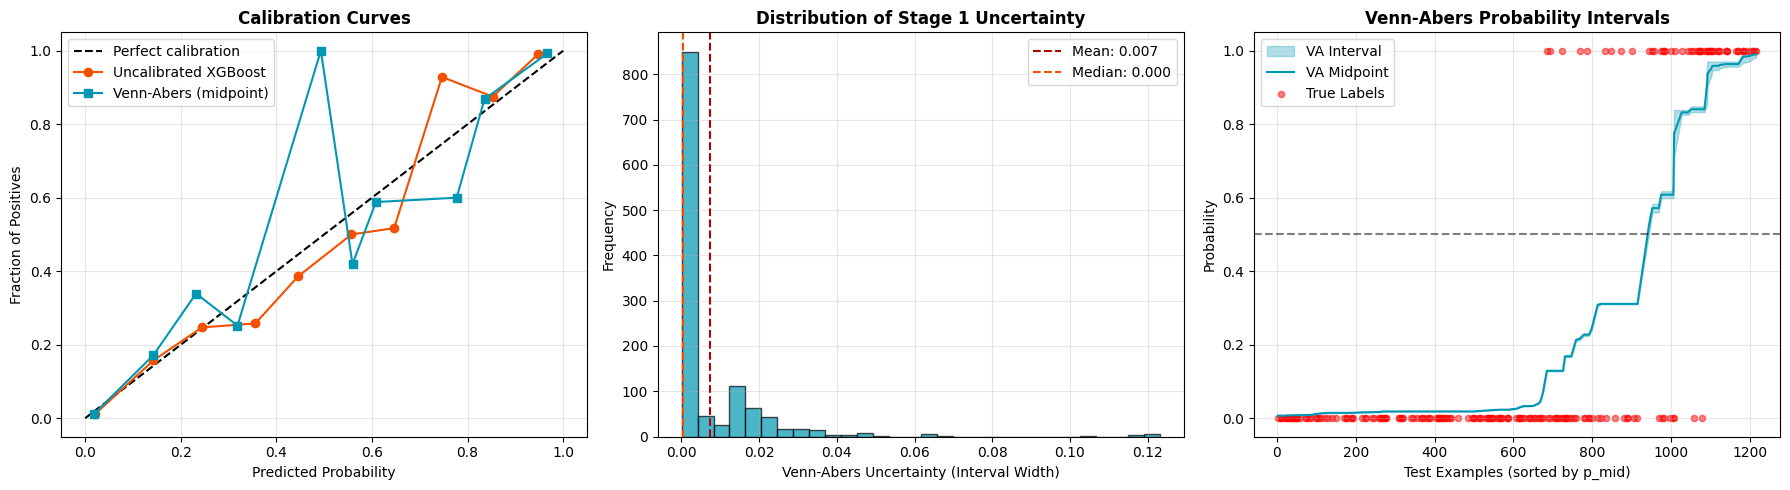

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Calibration curve comparison
ax = axes[0]
fraction_of_positives_uncal, mean_predicted_value_uncal = calibration_curve(
    y_test_binary, p_test_uncalibrated, n_bins=10
)
fraction_of_positives_va, mean_predicted_value_va = calibration_curve(
    y_test_binary, p_mid, n_bins=10
)
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.plot(mean_predicted_value_uncal, fraction_of_positives_uncal, 'o-', 
        label='Uncalibrated XGBoost', color=color_orange)
ax.plot(mean_predicted_value_va, fraction_of_positives_va, 's-', 
        label='Venn-Abers (midpoint)', color=color_azure)
ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curves', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Uncertainty distribution
ax = axes[1]
ax.hist(va_uncertainty, bins=30, color=color_azure, alpha=0.7, edgecolor='black')
ax.axvline(va_uncertainty.mean(), color=color_red, linestyle='--', 
           label=f'Mean: {va_uncertainty.mean():.3f}')
ax.axvline(np.median(va_uncertainty), color=color_orange, linestyle='--', 
           label=f'Median: {np.median(va_uncertainty):.3f}')
ax.set_xlabel('Venn-Abers Uncertainty (Interval Width)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Stage 1 Uncertainty', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Probability intervals
ax = axes[2]
indices_sorted = np.argsort(p_mid)
x_plot = np.arange(len(indices_sorted))
sample_indices = np.random.choice(len(indices_sorted), min(200, len(indices_sorted)), replace=False)
sample_indices = sorted(sample_indices)

ax.fill_between(x_plot[sample_indices], 
                p_lower[indices_sorted][sample_indices], 
                p_upper[indices_sorted][sample_indices],
                alpha=0.3, color=color_azure, label='VA Interval')
ax.plot(x_plot[sample_indices], p_mid[indices_sorted][sample_indices], 
        color=color_azure, label='VA Midpoint')
ax.scatter(x_plot[sample_indices], y_test_binary.values[indices_sorted][sample_indices], 
           c='red', s=20, alpha=0.5, label='True Labels')
ax.axhline(0.5, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Test Examples (sorted by p_mid)')
ax.set_ylabel('Probability')
ax.set_title('Venn-Abers Probability Intervals', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('stage1_venn_abers_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

### Decision Logic: Which patients proceed to Stage 2?

We'll use **both probability and uncertainty** from Venn-Abers to decide:

In [11]:
# Define thresholds
CONFIDENCE_THRESHOLD = 0.3  # Maximum uncertainty to be considered "confident"
PROBABILITY_THRESHOLD = 0.5  # Minimum p_lower to proceed

# Decision rule: Proceed to Stage 2 if:
# 1. High confidence (low uncertainty) AND p_lower > 0.5, OR
# 2. Moderate uncertainty but high probability (p_mid > 0.7)
proceed_to_stage2_confident = (p_lower > PROBABILITY_THRESHOLD) & (va_uncertainty < CONFIDENCE_THRESHOLD)
proceed_to_stage2_moderate = (p_mid > 0.7) & (va_uncertainty < 0.5)
proceed_to_stage2 = proceed_to_stage2_confident | proceed_to_stage2_moderate

# Create uncertainty categories for stratification
uncertainty_category = np.zeros(len(va_uncertainty), dtype=int)
uncertainty_category[(va_uncertainty >= 0) & (va_uncertainty < 0.15)] = 0  # Low uncertainty
uncertainty_category[(va_uncertainty >= 0.15) & (va_uncertainty < 0.3)] = 1  # Medium uncertainty
uncertainty_category[va_uncertainty >= 0.3] = 2  # High uncertainty

print("\n=== Stage 2 Filtering Results ===")
print(f"Total test samples: {len(y_test_binary)}")
print(f"Samples proceeding to Stage 2: {proceed_to_stage2.sum()} ({proceed_to_stage2.mean()*100:.1f}%)")
print(f"  - High confidence: {proceed_to_stage2_confident.sum()}")
print(f"  - Moderate confidence: {(proceed_to_stage2_moderate & ~proceed_to_stage2_confident).sum()}")
print(f"\nSamples by uncertainty category (proceeding to Stage 2):")
for cat, name in enumerate(['Low', 'Medium', 'High']):
    mask = (uncertainty_category == cat) & proceed_to_stage2
    print(f"  {name}: {mask.sum()} samples")

print(f"\nTrue positive rate among filtered samples: {y_test_binary[proceed_to_stage2].mean():.3f}")


=== Stage 2 Filtering Results ===
Total test samples: 1221
Samples proceeding to Stage 2: 269 (22.0%)
  - High confidence: 269
  - Moderate confidence: 0

Samples by uncertainty category (proceeding to Stage 2):
  Low: 269 samples
  Medium: 0 samples
  High: 0 samples

True positive rate among filtered samples: 0.844


## 3. Stage 2: Conformal Prediction for Medication Dose

Now we'll run conformal prediction **only on samples that passed Stage 1 filtering**, and we'll use VA uncertainty to inform the conformal prediction.

In [12]:
# Get corresponding continuous outcomes for test set
y_continuous_test = y_continuous[X_test.index]

# Filter for Stage 2
X_test_stage2 = X_test[proceed_to_stage2]
y_test_stage2 = y_continuous_test[proceed_to_stage2]
va_uncertainty_stage2 = va_uncertainty[proceed_to_stage2]
p_mid_stage2 = p_mid[proceed_to_stage2]
uncertainty_category_stage2 = uncertainty_category[proceed_to_stage2]

print(f"\nStage 2 dataset size: {len(X_test_stage2)}")
print(f"Mean LEDD change: {y_test_stage2.mean():.3f}")
print(f"Std LEDD change: {y_test_stage2.std():.3f}")


Stage 2 dataset size: 269
Mean LEDD change: 0.025
Std LEDD change: 0.646


In [13]:
# Prepare training data for Stage 2 regression
# Use samples where y_binary == 1 (medication change needed)
stage2_train_mask = y_binary[X_train.index] == 1
X_train_stage2 = X_train[stage2_train_mask]
y_train_stage2 = y_continuous[X_train.index][stage2_train_mask]

print(f"Stage 2 training set size: {len(X_train_stage2)}")
print(f"Mean LEDD change in training: {y_train_stage2.mean():.3f}")

Stage 2 training set size: 922
Mean LEDD change in training: 0.014


In [14]:
# Train XGBoost regressor for Stage 2
regression_params = {
    'alpha': 0.1, 
    'lambda': 1, 
    'learning_rate': 0.1, 
    'max_depth': 7, 
    'n_estimators': 700, 
    "eval_metric": 'rmse', 
    'objective': 'reg:squarederror', 
    'sampling_method': 'gradient_based', 
    'tree_method': 'hist', 
    'device': "cuda"
}

xgb_model_stage2 = xgb.XGBRegressor(**regression_params, random_state=random_state)
xgb_model_stage2.fit(X_train_stage2, y_train_stage2)

# Quick evaluation
y_pred_stage2 = xgb_model_stage2.predict(X_test_stage2)
rmse = np.sqrt(mean_squared_error(y_test_stage2, y_pred_stage2))
mae = mean_absolute_error(y_test_stage2, y_pred_stage2)
r2 = r2_score(y_test_stage2, y_pred_stage2)

print(f"\nStage 2 Regression Performance (before conformal):")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE: {mae:.4f}")
print(f"  R²: {r2:.4f}")


Stage 2 Regression Performance (before conformal):
  RMSE: 0.2749
  MAE: 0.1249
  R²: 0.8184


/home/rdiazrincon/.local/lib/python3.10/site-packages/xgboost/core.py:160: UserWarning: [15:53:23] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


### Strategy 1: Baseline Conformal Prediction (No VA Information)

In [15]:
STRATEGIES_BASELINE = {
    "naive": {"method": "naive"},
    "cv_plus": {"method": "plus", "cv": 10},
    "jackknife_plus_ab": {"method": "plus", "cv": Subsample(n_resamplings=50)},
}

alpha = 0.2
results_baseline = {}

print("\nRunning baseline conformal prediction (without VA information)...")
for strategy, params in STRATEGIES_BASELINE.items():
    print(f"  - {strategy}")
    mapie = MapieRegressor(xgb_model_stage2, test_size=0.2, **params, random_state=random_state)
    mapie.fit(X_train_stage2, y_train_stage2)
    y_pred, y_pis = mapie.predict(X_test_stage2, alpha=alpha)
    
    coverage = regression_coverage_score(y_test_stage2, y_pis[:, 0, 0], y_pis[:, 1, 0])
    width = regression_mean_width_score(y_pis[:, 0, 0], y_pis[:, 1, 0])
    
    results_baseline[strategy] = {
        'y_pred': y_pred,
        'y_pis': y_pis,
        'coverage': coverage,
        'width': width
    }
    print(f"      Coverage: {coverage:.4f}, Width: {width:.4f}")


Running baseline conformal prediction (without VA information)...
  - naive


/home/rdiazrincon/.local/lib/python3.10/site-packages/mapie/utils.py:621: UserWarning: WARNING: The predictions are ill-sorted.
  warnings.warn(


      Coverage: 0.5279, Width: 0.0403
  - cv_plus


/home/rdiazrincon/.local/lib/python3.10/site-packages/mapie/utils.py:621: UserWarning: WARNING: The predictions are ill-sorted.
  warnings.warn(


      Coverage: 0.7881, Width: 0.1972
  - jackknife_plus_ab
      Coverage: 0.6059, Width: 0.1965


/home/rdiazrincon/.local/lib/python3.10/site-packages/mapie/utils.py:621: UserWarning: WARNING: The predictions are ill-sorted.
  warnings.warn(


### Strategy 2: Stratified Conformal Prediction by VA Uncertainty

In [16]:
# Custom stratified conformal prediction
def stratified_conformal_prediction(X_train, y_train, X_test, y_test, 
                                   strata_test, method="naive", alpha=0.2):
    """
    Perform conformal prediction separately for each stratum (uncertainty category)
    """
    unique_strata = np.unique(strata_test)
    n_test = len(X_test)
    
    # Initialize outputs
    y_pred_all = np.zeros(n_test)
    y_lower_all = np.zeros(n_test)
    y_upper_all = np.zeros(n_test)
    
    for stratum in unique_strata:
        # Get test indices for this stratum
        test_mask = (strata_test == stratum)
        X_test_stratum = X_test[test_mask]
        
        if len(X_test_stratum) == 0:
            continue
        
        # Fit MAPIE for this stratum
        if method == "naive":
            params = {"method": "naive"}
        elif method == "cv_plus":
            params = {"method": "plus", "cv": 10}
        elif method == "jackknife_plus_ab":
            params = {"method": "plus", "cv": Subsample(n_resamplings=50)}
        
        mapie = MapieRegressor(xgb_model_stage2, test_size=0.2, **params, random_state=random_state)
        mapie.fit(X_train, y_train)
        y_pred_stratum, y_pis_stratum = mapie.predict(X_test_stratum, alpha=alpha)
        
        # Store results
        y_pred_all[test_mask] = y_pred_stratum.flatten()
        y_lower_all[test_mask] = y_pis_stratum[:, 0, 0]
        y_upper_all[test_mask] = y_pis_stratum[:, 1, 0]
    
    return y_pred_all, y_lower_all, y_upper_all

print("\nRunning stratified conformal prediction (by VA uncertainty)...")
results_stratified = {}

for strategy in ["naive", "cv_plus", "jackknife_plus_ab"]:
    print(f"  - {strategy}")
    y_pred, y_lower, y_upper = stratified_conformal_prediction(
        X_train_stage2, y_train_stage2, X_test_stage2, y_test_stage2,
        uncertainty_category_stage2, method=strategy, alpha=alpha
    )
    
    coverage = np.mean((y_test_stage2 >= y_lower) & (y_test_stage2 <= y_upper))
    width = np.mean(y_upper - y_lower)
    
    results_stratified[strategy] = {
        'y_pred': y_pred,
        'y_lower': y_lower,
        'y_upper': y_upper,
        'coverage': coverage,
        'width': width
    }
    print(f"      Coverage: {coverage:.4f}, Width: {width:.4f}")


Running stratified conformal prediction (by VA uncertainty)...
  - naive
      Coverage: 0.5279, Width: 0.0403
  - cv_plus
      Coverage: 0.7881, Width: 0.1972
  - jackknife_plus_ab
      Coverage: 0.5836, Width: 0.1958


### Strategy 3: VA-Augmented Features for Conformal Prediction

In [17]:
# Add VA features to Stage 2 features
# First, get VA probabilities for training set
d_train_va = xgb.DMatrix(X_train)
p_train_uncalibrated = model_stage1.predict(d_train_va, iteration_range=(0, model_stage1.best_iteration + 1))

# Convert to 2D for VennAbers
p_train_2d = np.column_stack([1 - p_train_uncalibrated, p_train_uncalibrated])

# Get VA predictions for training set
p_train_lower_2d, p_train_upper_2d = va.predict_proba(p_train_2d)

# Extract class 1 probabilities only
p_train_lower = p_train_lower_2d[:, 1]
p_train_upper = p_train_upper_2d[:, 1]
p_train_mid = (p_train_lower + p_train_upper) / 2
va_train_uncertainty = p_train_upper - p_train_lower

# Filter for Stage 2 training samples
p_train_lower_stage2 = p_train_lower[stage2_train_mask]
p_train_upper_stage2 = p_train_upper[stage2_train_mask]
p_train_mid_stage2 = p_train_mid[stage2_train_mask]
va_train_uncertainty_stage2 = va_train_uncertainty[stage2_train_mask]

# Augment features
X_train_stage2_augmented = np.column_stack([
    X_train_stage2,
    p_train_lower_stage2,
    p_train_upper_stage2,
    va_train_uncertainty_stage2
])

X_test_stage2_augmented = np.column_stack([
    X_test_stage2,
    p_lower[proceed_to_stage2],
    p_upper[proceed_to_stage2],
    va_uncertainty_stage2
])

print(f"\nAugmented features shape: {X_train_stage2_augmented.shape}")
print(f"Original features: {X_train_stage2.shape[1]}")
print(f"Added VA features: 3 (p_lower, p_upper, uncertainty)")


Augmented features shape: (922, 42)
Original features: 39
Added VA features: 3 (p_lower, p_upper, uncertainty)


In [18]:
# Train model with augmented features
xgb_model_augmented = xgb.XGBRegressor(**regression_params, random_state=random_state)
xgb_model_augmented.fit(X_train_stage2_augmented, y_train_stage2)

print("\nRunning conformal prediction with VA-augmented features...")
results_augmented = {}

for strategy, params in STRATEGIES_BASELINE.items():
    print(f"  - {strategy}")
    mapie = MapieRegressor(xgb_model_augmented, test_size=0.2, **params, random_state=random_state)
    mapie.fit(X_train_stage2_augmented, y_train_stage2)
    y_pred, y_pis = mapie.predict(X_test_stage2_augmented, alpha=alpha)
    
    coverage = regression_coverage_score(y_test_stage2, y_pis[:, 0, 0], y_pis[:, 1, 0])
    width = regression_mean_width_score(y_pis[:, 0, 0], y_pis[:, 1, 0])
    
    results_augmented[strategy] = {
        'y_pred': y_pred,
        'y_pis': y_pis,
        'coverage': coverage,
        'width': width
    }
    print(f"      Coverage: {coverage:.4f}, Width: {width:.4f}")


Running conformal prediction with VA-augmented features...
  - naive


/home/rdiazrincon/.local/lib/python3.10/site-packages/mapie/utils.py:621: UserWarning: WARNING: The predictions are ill-sorted.
  warnings.warn(


      Coverage: 0.5019, Width: 0.0344
  - cv_plus


/home/rdiazrincon/.local/lib/python3.10/site-packages/mapie/utils.py:621: UserWarning: WARNING: The predictions are ill-sorted.
  warnings.warn(


      Coverage: 0.8104, Width: 0.3085
  - jackknife_plus_ab
      Coverage: 0.5911, Width: 0.2141


/home/rdiazrincon/.local/lib/python3.10/site-packages/mapie/utils.py:621: UserWarning: WARNING: The predictions are ill-sorted.
  warnings.warn(


## 4. Comprehensive Results Comparison

In [19]:
# Create comparison table
comparison_data = []

for strategy in ["naive", "cv_plus", "jackknife_plus_ab"]:
    comparison_data.append({
        'Strategy': f'{strategy} (baseline)',
        'Coverage': results_baseline[strategy]['coverage'],
        'Width': results_baseline[strategy]['width']
    })
    comparison_data.append({
        'Strategy': f'{strategy} (VA-stratified)',
        'Coverage': results_stratified[strategy]['coverage'],
        'Width': results_stratified[strategy]['width']
    })
    comparison_data.append({
        'Strategy': f'{strategy} (VA-augmented)',
        'Coverage': results_augmented[strategy]['coverage'],
        'Width': results_augmented[strategy]['width']
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*70)
print("STAGE 2 CONFORMAL PREDICTION: RESULTS COMPARISON")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)


STAGE 2 CONFORMAL PREDICTION: RESULTS COMPARISON
                         Strategy  Coverage    Width
                 naive (baseline)  0.527881 0.040316
            naive (VA-stratified)  0.527881 0.040316
             naive (VA-augmented)  0.501859 0.034422
               cv_plus (baseline)  0.788104 0.197246
          cv_plus (VA-stratified)  0.788104 0.197246
           cv_plus (VA-augmented)  0.810409 0.308500
     jackknife_plus_ab (baseline)  0.605948 0.196499
jackknife_plus_ab (VA-stratified)  0.583643 0.195812
 jackknife_plus_ab (VA-augmented)  0.591078 0.214114


## 5. Visualization: Compare All Approaches

In [20]:
# Plotting function from your original code (adapted)
def plot_prediction_intervals_enhanced(
    axs, y_test, y_pred, y_lower, y_upper, 
    coverage, width, title, num_samples=200
):
    """
    Enhanced version of your plotting function
    """
    # Sample for visualization
    if len(y_test) > num_samples:
        indices = np.random.choice(len(y_test), num_samples, replace=False)
    else:
        indices = np.arange(len(y_test))
    
    y_test_plot = y_test.values[indices] if hasattr(y_test, 'values') else y_test[indices]
    y_pred_plot = y_pred[indices]
    y_lower_plot = y_lower[indices]
    y_upper_plot = y_upper[indices]
    
    error = y_pred_plot - y_lower_plot
    warnings = (y_test_plot > y_upper_plot) | (y_test_plot < y_lower_plot)
    
    # Plot points inside intervals
    axs.errorbar(
        y_test_plot[~warnings],
        y_pred_plot[~warnings],
        yerr=np.abs(error[~warnings]),
        fmt='o', capsize=5, elinewidth=2, linewidth=0,
        color=color_azure, alpha=0.6,
        label="Inside prediction interval"
    )
    
    # Plot points outside intervals
    axs.errorbar(
        y_test_plot[warnings],
        y_pred_plot[warnings],
        yerr=np.abs(error[warnings]),
        fmt='x', capsize=5, elinewidth=2, linewidth=0,
        color=color_red, alpha=0.8,
        label="Outside prediction interval"
    )
    
    # Mark true values for points outside
    axs.scatter(
        y_test_plot[warnings],
        y_test_plot[warnings],
        marker="*", s=100, color="green", alpha=0.7,
        label="True value"
    )
    
    # Formatting
    axs.set_xlabel("True Percent Change of LEDD", fontsize=10)
    axs.set_ylabel("Predicted Percent Change of LEDD", fontsize=10)
    axs.grid(True, linestyle='--', alpha=0.4, linewidth=0.8)
    
    lims = [
        np.min([axs.get_xlim(), axs.get_ylim()]),
        np.max([axs.get_xlim(), axs.get_ylim()]),
    ]
    axs.plot(lims, lims, '--', alpha=0.75, color="black", linewidth=2, label="x=y")
    
    # Add text box with metrics
    from matplotlib.offsetbox import AnchoredText
    textstr = f'Coverage: {coverage:.3f}\nWidth: {width:.3f}'
    anchored_text = AnchoredText(textstr, loc='upper left', prop=dict(size=10), frameon=True)
    anchored_text.patch.set_boxstyle("round,pad=0.3")
    anchored_text.patch.set_alpha(0.9)
    axs.add_artist(anchored_text)
    
    axs.set_title(title, fontweight='bold', fontsize=12)
    axs.set_xlim(lims)
    axs.set_ylim(lims)

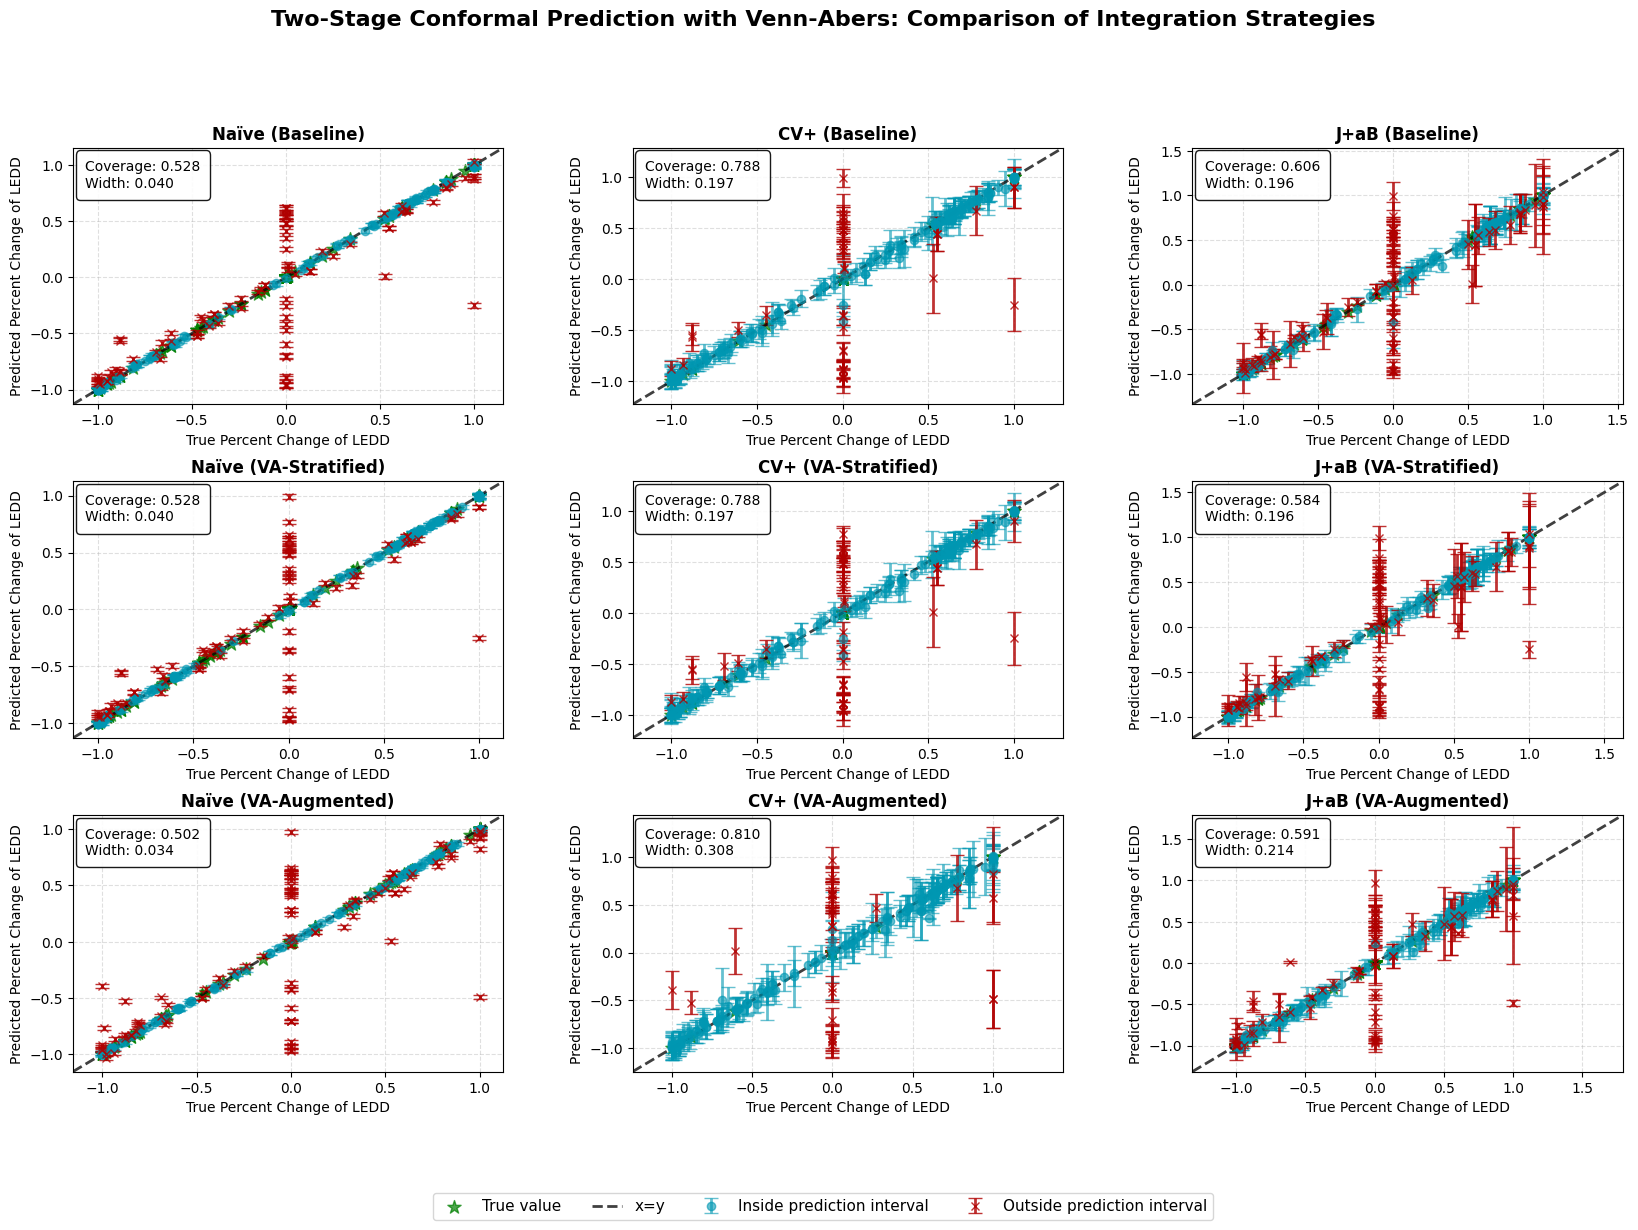

In [21]:
# Create comprehensive visualization
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

strategies_list = ["naive", "cv_plus", "jackknife_plus_ab"]
strategy_names = ["Naïve", "CV+", "J+aB"]

# Row 1: Baseline
for i, (strategy, name) in enumerate(zip(strategies_list, strategy_names)):
    ax = fig.add_subplot(gs[0, i])
    res = results_baseline[strategy]
    plot_prediction_intervals_enhanced(
        ax, y_test_stage2, res['y_pred'], 
        res['y_pis'][:, 0, 0], res['y_pis'][:, 1, 0],
        res['coverage'], res['width'],
        f"{name} (Baseline)"
    )

# Row 2: VA-Stratified
for i, (strategy, name) in enumerate(zip(strategies_list, strategy_names)):
    ax = fig.add_subplot(gs[1, i])
    res = results_stratified[strategy]
    plot_prediction_intervals_enhanced(
        ax, y_test_stage2, res['y_pred'],
        res['y_lower'], res['y_upper'],
        res['coverage'], res['width'],
        f"{name} (VA-Stratified)"
    )

# Row 3: VA-Augmented
for i, (strategy, name) in enumerate(zip(strategies_list, strategy_names)):
    ax = fig.add_subplot(gs[2, i])
    res = results_augmented[strategy]
    plot_prediction_intervals_enhanced(
        ax, y_test_stage2, res['y_pred'],
        res['y_pis'][:, 0, 0], res['y_pis'][:, 1, 0],
        res['coverage'], res['width'],
        f"{name} (VA-Augmented)"
    )

# Add overall title
fig.suptitle(
    'Two-Stage Conformal Prediction with Venn-Abers: Comparison of Integration Strategies',
    fontsize=16, fontweight='bold', y=0.995
)

# Add legend
handles, labels = fig.axes[0].get_legend_handles_labels()
fig.legend(handles[:4], labels[:4], loc='lower center', ncol=4, 
          bbox_to_anchor=(0.5, -0.02), fontsize=11, frameon=True)

plt.savefig('comprehensive_venn_abers_conformal_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Analysis: Coverage by Uncertainty Category

In [22]:
# Analyze coverage within each uncertainty category
def analyze_coverage_by_category(y_test, y_lower, y_upper, categories):
    results = []
    for cat, name in enumerate(['Low Uncertainty', 'Medium Uncertainty', 'High Uncertainty']):
        mask = (categories == cat)
        if mask.sum() == 0:
            continue
        
        y_test_cat = y_test.values[mask] if hasattr(y_test, 'values') else y_test[mask]
        coverage = np.mean((y_test_cat >= y_lower[mask]) & (y_test_cat <= y_upper[mask]))
        width = np.mean(y_upper[mask] - y_lower[mask])
        
        results.append({
            'Uncertainty Category': name,
            'N Samples': mask.sum(),
            'Coverage': coverage,
            'Mean Width': width
        })
    
    return pd.DataFrame(results)

print("\n" + "="*80)
print("COVERAGE ANALYSIS BY STAGE 1 UNCERTAINTY CATEGORY")
print("="*80)

for strategy in strategies_list:
    print(f"\n{strategy.upper()} - Stratified Approach:")
    res = results_stratified[strategy]
    df_analysis = analyze_coverage_by_category(
        y_test_stage2, res['y_lower'], res['y_upper'], uncertainty_category_stage2
    )
    print(df_analysis.to_string(index=False))


COVERAGE ANALYSIS BY STAGE 1 UNCERTAINTY CATEGORY

NAIVE - Stratified Approach:
Uncertainty Category  N Samples  Coverage  Mean Width
     Low Uncertainty        269  0.527881    0.040316

CV_PLUS - Stratified Approach:
Uncertainty Category  N Samples  Coverage  Mean Width
     Low Uncertainty        269  0.788104    0.197246

JACKKNIFE_PLUS_AB - Stratified Approach:
Uncertainty Category  N Samples  Coverage  Mean Width
     Low Uncertainty        269  0.583643    0.195812
